# NOTEBOOK 04 — Backtesting

---

## Objective

This notebook simulates the historical performance of the 12-1 momentum
strategy on S&P 500 equities over the in-sample period (2011–2018).

The backtest answers a concrete question:

> *If a trader had followed the momentum signal mechanically from 2011 to 2018,
> rebalancing every month, what would the realized portfolio returns have been?*

---

## Portfolio Construction Rules

| Parameter | Value |
|---|---|
| Universe | S&P 500 large caps (449 tickers) |
| Signal | 12-1 month cross-sectional momentum |
| Long leg | Quintile 5 (top 20% momentum scores) |
| Short leg | Quintile 1 (bottom 20% momentum scores) |
| Weighting | Equal weight within each quintile |
| Rebalancing | Monthly (at month-end) |
| Portfolio type | Dollar-neutral long/short |

---

## Dollar-Neutral Portfolio

The portfolio is **dollar-neutral**: for every $\$1$ invested long in Q5,
$\$1$ is sold short in Q1. This means:

- The portfolio has **zero net market exposure** by construction
- Returns are generated purely from the **spread between winners and losers**
- The strategy is approximately market-neutral — it does not depend on
  whether the overall market goes up or down

---

## Transaction Cost Model

Every monthly rebalancing incurs costs from three sources:

### 1. Transaction Costs (paid on every trade)
Each time a stock enters or exits the portfolio, we pay:

$$\text{Cost per trade} = \text{bid-ask spread} + \text{commissions} + \text{market impact}$$

For S&P 500 large caps, this is approximately **5 basis points (bps)** per trade,
where 1 bp = 0.01% of the transaction value.

The total monthly transaction cost depends on **portfolio turnover** —
the fraction of the portfolio that changes each month:

$$\text{Transaction cost}_t = \text{Turnover}_t \times \text{Cost per trade}$$

### 2. Borrow Fee (paid continuously on the short leg)
To short a stock, the trader must borrow it from another investor
(typically an institutional owner such as a pension fund) and pay
a **borrow fee** — an annualized rate applied to the value of the
short position:

$$\text{Borrow cost}_t = \text{Short portfolio value} \times \frac{\text{Borrow fee (annual)}}{12}$$

For S&P 500 large caps, the borrow fee is typically **0.3–1.0% per year**,
as these stocks are widely held and easy to borrow. We use **0.5% annually**
as our base case estimate.

### 3. Sensitivity Analysis
We compute net returns under three cost scenarios to assess robustness:

| Scenario | Cost per trade | Borrow fee (annual) |
|---|---|---|
| Optimistic | 3 bps | 0.3% |
| Base | 5 bps | 0.5% |
| Pessimistic | 10 bps | 1.0% |

---

## Performance Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **CAGR** | $(1 + r_{total})^{1/T} - 1$ | Annualized compounded return |
| **Volatility** | $\sigma_r \times \sqrt{12}$ | Annualized standard deviation |
| **Sharpe Ratio** | $\text{CAGR} / \text{Volatility}$ | Return per unit of risk |
| **Max Drawdown** | $\max(1 - V_t / \max_{s \leq t} V_s)$ | Worst peak-to-trough loss |
| **Calmar Ratio** | $\text{CAGR} / \text{Max Drawdown}$ | Return per unit of drawdown risk |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# Load data
prices    = pd.read_parquet('../data/sp500_prices.parquet')
momentum  = pd.read_parquet('../data/momentum_signal.parquet')
quintiles = pd.read_parquet('../data/momentum_quintiles.parquet')

# In-sample period only
SPLIT_DATE  = '2018-12-31'
prices_is   = prices.loc[:'2018-12-31']
momentum_is = momentum.loc[:'2018-12-31']
quintiles_is= quintiles.loc[:'2018-12-31']

# Daily returns in-sample
daily_returns_is = prices_is.pct_change()

print("=== DATA LOADED ===")
print(f"Prices shape:    {prices_is.shape}")
print(f"Momentum shape:  {momentum_is.shape}")
print(f"Quintiles shape: {quintiles_is.shape}")
print(f"Period:          {prices_is.index[0].date()} → {prices_is.index[-1].date()}")

=== DATA LOADED ===
Prices shape:    (2264, 449)
Momentum shape:  (2264, 449)
Quintiles shape: (2264, 449)
Period:          2010-01-04 → 2018-12-31


# STEP 1: COMPUTE MONTHLY RETURNS FOR EACH QUINTILE


## THEORY
At each month-end date *t*, we:

1. Observe the quintile assignment for each stock (from notebook 02)  
2. Compute the **equal-weighted average return** of each quintile  
   over the following month (from *t* to *t + 21 trading days*)

---

## EQUAL WEIGHTING

Each stock within a quintile receives the same capital allocation.

- If Q5 contains 90 stocks, each receives **1/90** of the long portfolio value  
- Equal weighting is:
  - Simple  
  - Transparent  
  - Reduces concentration risk  

**Drawback:**
- Higher turnover compared to value-weighting  
- Even small price movements can change a stock’s quintile assignment  

---

## TIMING CONVENTION

- The portfolio is formed at month-end *t* using quintile assignments  
  based only on information available at time *t*  
- Returns are measured from *t* to *t + 1* (next month-end)  

This ensures **no lookahead bias** in the backtest.



In [18]:
def compute_quintile_returns(prices, quintiles):
    """
    Compute equal-weighted monthly returns for each quintile.

    Parameters
    ----------
    prices    : pd.DataFrame, adjusted closing prices (in-sample)
    quintiles : pd.DataFrame, quintile assignments 1-5 (in-sample)

    Returns
    -------
    quintile_returns : pd.DataFrame, monthly returns per quintile (columns Q1-Q5)
    """
    # Monthly prices at month-end
    monthly_prices = prices.resample('M').last()

    # Monthly returns from month-end to next month-end
    monthly_returns = monthly_prices.pct_change()

    # Quintile assignments at each month-end
    monthly_quintiles = quintiles.resample('M').last()

    records = []

    for i in range(1, len(monthly_prices)):
        date_signal = monthly_prices.index[i-1]  # formation date
        date_return = monthly_prices.index[i]     # return measurement date

        if date_signal not in monthly_quintiles.index:
            continue

        q_assignments = monthly_quintiles.loc[date_signal]
        month_rets     = monthly_returns.loc[date_return]

        row = {'date': date_return}

        for q in range(1, 6):
            # Stocks in this quintile with valid returns
            mask  = (q_assignments == q) & month_rets.notna()
            stocks = month_rets[mask]

            if len(stocks) > 0:
                row[f'Q{q}'] = stocks.mean()  # equal-weighted average
            else:
                row[f'Q{q}'] = np.nan

        records.append(row)

    quintile_returns = pd.DataFrame(records).set_index('date')
    return quintile_returns

quintile_returns = compute_quintile_returns(prices_is, quintiles_is)

print("=== MONTHLY QUINTILE RETURNS ===")
print(f"Observations: {len(quintile_returns)} months")
print(f"\nFirst 5 months:")
print(quintile_returns.head().round(4))
print(f"\nDescriptive statistics:")
print(quintile_returns.describe().round(4))

=== MONTHLY QUINTILE RETURNS ===
Observations: 107 months

First 5 months:
            Q1  Q2  Q3  Q4  Q5
date                          
2010-02-28 NaN NaN NaN NaN NaN
2010-03-31 NaN NaN NaN NaN NaN
2010-04-30 NaN NaN NaN NaN NaN
2010-05-31 NaN NaN NaN NaN NaN
2010-06-30 NaN NaN NaN NaN NaN

Descriptive statistics:
            Q1       Q2       Q3       Q4       Q5
count  95.0000  95.0000  95.0000  95.0000  95.0000
mean    0.0128   0.0125   0.0125   0.0118   0.0144
std     0.0447   0.0343   0.0340   0.0327   0.0382
min    -0.0930  -0.0940  -0.0921  -0.0807  -0.0998
25%    -0.0121  -0.0021  -0.0023  -0.0066  -0.0077
50%     0.0160   0.0157   0.0166   0.0159   0.0173
75%     0.0377   0.0300   0.0349   0.0324   0.0379
max     0.1634   0.1320   0.1130   0.1092   0.1340


## Monthly Quintile Returns — Notes

The backtest produces **95 valid monthly observations** out of 107 total
month-end dates. The first 12 months (2010-02-28 → 2010-12-31) are NaN
by construction — the momentum signal requires 252 trading days of history
before producing valid scores, so no quintile assignments exist before
January 2011.

Key observations from the descriptive statistics:

- **Mean returns are nearly identical across quintiles** (Q1: 1.28%, Q5: 1.44%
  per month), reflecting the strong bull market of 2011-2018 where almost
  all large-cap stocks appreciated. The absolute return level is driven by
  market beta, not by the momentum signal.

- **Q5 has the highest mean return (1.44%)** and Q4 the lowest (1.18%),
  but the differences are small relative to the standard deviation (~3-4%),
  confirming the weak IC observed in Notebook 03.

- **Q1 has the highest standard deviation (4.47%)** — losers are more volatile
  than winners, a well-documented empirical regularity. This has implications
  for the long/short portfolio: the short leg contributes disproportionately
  to portfolio volatility.

# STEP 2: COMPUTE MONTHLY PORTFOLIO TURNOVER


## THEORY

Turnover measures the fraction of the portfolio that is traded each month.

- **100% turnover** → the entire portfolio is replaced every month  
- **30% turnover** → 30% of holdings change, 70% are carried over  

For a momentum strategy, turnover is driven by stocks moving between  
quintiles from one month to the next.

- Stocks that **remain** in Q5 or Q1 → *no transaction costs*  
- Stocks that **enter or exit** → *generate trading activity*  

---

## TURNOVER FORMULA

For each leg (**long** and **short**) separately:

$$
\text{Turnover}_t = \frac{\text{Number of stocks entering the quintile at } t}{\text{Total number of stocks in the quintile}}
$$

---

## TOTAL PORTFOLIO TURNOVER

The overall turnover is defined as:

$$
\text{Turnover}^{\text{Total}}_t = \frac{\text{Turnover}^{\text{Long}}_t + \text{Turnover}^{\text{Short}}_t}{2}
$$

This is appropriate because the portfolio is **dollar-neutral**.

In [21]:
def compute_turnover(quintiles):
    """
    Compute monthly portfolio turnover for the long (Q5) and short (Q1) legs.

    Parameters
    ----------
    quintiles : pd.DataFrame, quintile assignments (in-sample)

    Returns
    -------
    turnover : pd.DataFrame, monthly turnover for Q1, Q5, and average
    """
    monthly_quintiles = quintiles.resample('M').last()
    records = []

    for i in range(1, len(monthly_quintiles)):
        date_prev = monthly_quintiles.index[i-1]
        date_curr = monthly_quintiles.index[i]

        q_prev = monthly_quintiles.loc[date_prev]
        q_curr = monthly_quintiles.loc[date_curr]

        for q in [1, 5]:
            stocks_prev = set(q_prev[q_prev == q].index)
            stocks_curr = set(q_curr[q_curr == q].index)

            # Stocks that entered the quintile this month
            new_entries = stocks_curr - stocks_prev

            if len(stocks_curr) > 0:
                turnover_q = len(new_entries) / len(stocks_curr)
            else:
                turnover_q = np.nan

            records.append({
                'date'    : date_curr,
                'quintile': f'Q{q}',
                'turnover': turnover_q
            })

    df = pd.DataFrame(records)
    turnover = df.pivot(index='date', columns='quintile', values='turnover')
    turnover['average'] = turnover[['Q1', 'Q5']].mean(axis=1)

    return turnover

turnover = compute_turnover(quintiles_is)

print("=== MONTHLY TURNOVER ===")
print(f"\nAverage monthly turnover:")
print(turnover.mean().round(4))
print(f"\nFirst 5 months:")
print(turnover.head().round(4))

=== MONTHLY TURNOVER ===

Average monthly turnover:
quintile
Q1         0.2437
Q5         0.2441
average    0.2439
dtype: float64

First 5 months:
quintile    Q1  Q5  average
date                       
2010-02-28 NaN NaN      NaN
2010-03-31 NaN NaN      NaN
2010-04-30 NaN NaN      NaN
2010-05-31 NaN NaN      NaN
2010-06-30 NaN NaN      NaN


## Portfolio Turnover — Notes

Average monthly turnover is **24.4%** for both the long (Q5) and short (Q1)
legs — nearly identical, which is expected given the symmetric quintile
construction.

A turnover of 24.4% means that approximately **22 out of 90 stocks**
change in each quintile every month. The remaining ~68 stocks are carried
over from the previous month without generating transaction costs.

This turnover level is typical for a monthly-rebalanced momentum strategy.
It implies that the average stock remains in the portfolio for approximately
4 months (1 / 24.4% ≈ 4.1 months) before being replaced — consistent
with the known persistence of the momentum effect at medium-term horizons.

# STEP 3: COMPUTE TRANSACTION COSTS AND BORROW FEES


## THEORY

We model two distinct cost components:

---

### 1. TRANSACTION COSTS

Transaction costs are applied to the fraction of the portfolio traded each month (i.e. turnover).

- Expressed in **basis points (bps)**  
  - \( $1 \text{ bp} = 0.01\%$ \)  
- Include:
  - Bid-ask spread  
  - Broker commissions  
  - Market impact  

For large-cap stocks:

- Spread alone is typically **~2–3 bps**  
- We assume **5 bps** as a conservative estimate including all components  

---

### 2. BORROW FEE

The borrow fee is applied continuously to the **entire short leg** of the portfolio.

- Required because stocks must be **borrowed** before short selling  
- Paid as an **annualized rate** to the lender  

For :contentReference[oaicite:1]{index=1} stocks:

- Typical range: **0.3% – 1.0% per year**  
- Base assumption: **0.5% annually**

---

## COST IMPLEMENTATION

### Transaction Costs (per period)

$$
\text{Cost}^{\text{TC}}_t = \text{Turnover}_t \times c
$$

where:
-  c  = transaction cost in decimal form (e.g. 5 bps = 0.0005)

---

### Borrow Fee (per period)

$$
\text{Cost}^{\text{Borrow}}_t = \frac{r_{\text{borrow}}}{12}
$$

where:
-  $r_{\text{borrow}}$  = annual borrow fee  

---

## SENSITIVITY ANALYSIS

We test three scenarios to evaluate robustness to cost assumptions:

| Scenario       | Transaction Cost | Borrow Fee |
|----------------|----------------|-----------|
| Optimistic     | 3 bps          | 0.3%      |
| Base           | 5 bps          | 0.5%      |
| Pessimistic    | 10 bps         | 1.0%      |

---

These scenarios help assess how sensitive the strategy performance is  
to realistic variations in trading and financing costs.

In [26]:
# Cost scenarios
SCENARIOS = {
    'Optimistic' : {'cost_bps': 3,  'borrow_annual': 0.003},
    'Base'       : {'cost_bps': 5,  'borrow_annual': 0.005},
    'Pessimistic': {'cost_bps': 10, 'borrow_annual': 0.010},
}

def compute_costs(turnover, scenarios):
    """
    Compute monthly transaction costs and borrow fees for each scenario.

    Parameters
    ----------
    turnover  : pd.DataFrame, monthly turnover (Q1, Q5, average)
    scenarios : dict, cost parameters per scenario

    Returns
    -------
    costs : dict of pd.Series, monthly total costs per scenario
    """
    costs = {}

    for name, params in scenarios.items():
        cost_per_trade = params['cost_bps'] / 10000
        borrow_monthly = params['borrow_annual'] / 12

        # Transaction cost: applied to both legs (long + short turnover)
        transaction_cost = (
            turnover['Q5'] * cost_per_trade +   # long leg
            turnover['Q1'] * cost_per_trade      # short leg
        )

        # Borrow fee: applied to full short leg value every month
        borrow_cost = borrow_monthly

        # Total monthly cost
        costs[name] = transaction_cost + borrow_cost

    return costs

costs = compute_costs(turnover, SCENARIOS)

print("=== TRANSACTION COSTS ===")
print(f"\nAverage monthly costs per scenario:")
for name, cost_series in costs.items():
    print(f"  {name:12}: {cost_series.mean()*100:.4f}% per month  "
          f"({cost_series.mean()*100*12:.3f}% per year)")

=== TRANSACTION COSTS ===

Average monthly costs per scenario:
  Optimistic  : 0.0396% per month  (0.476% per year)
  Base        : 0.0661% per month  (0.793% per year)
  Pessimistic : 0.1321% per month  (1.585% per year)


## Transaction Costs — Notes

| Scenario | Monthly Cost | Annual Cost |
|---|---|---|
| Optimistic | 0.040% | 0.476% |
| Base | 0.066% | 0.793% |
| Pessimistic | 0.132% | 1.585% |

The monthly cost structure has two components:

**Transaction costs** (turnover × cost per trade): with 24.4% average turnover
applied to both legs, and 5 bps per trade in the base scenario, the
transaction component is approximately 0.024% per month per leg,
or 0.049% combined.

**Borrow fee** (fixed monthly charge on short leg): 0.5% annual / 12 =
0.042% per month, applied regardless of turnover.

Note that the **borrow fee dominates** over transaction costs in all scenarios
— this is characteristic of long/short equity strategies on liquid large-cap
stocks, where bid-ask spreads are minimal but the cost of maintaining a
short position is continuous and unavoidable.

# STEP 4: CONSTRUCT LONG/SHORT PORTFOLIO RETURNS


## THEORY

The long/short portfolio return at each month \( t \) is:

$$
r_{\text{gross}}(t) = r_{Q5}(t) - r_{Q1}(t)
$$

This represents the return of a **dollar-neutral portfolio** that is:

- **Long** \$1 in an equal-weighted basket of Q5 stocks  
- **Short** \$1 in an equal-weighted basket of Q1 stocks  

---

## NET RETURNS AFTER COSTS

The net return after accounting for trading and financing costs is:

$$
r_{\text{net}}(t) = r_{\text{gross}}(t) - \text{total\_costs}(t)
$$

---

## INTERPRETATION

In a dollar-neutral long/short portfolio:

- The **gross return** is already expressed as a return on the **long leg capital only**  
- The **short leg is self-financing**, meaning:
  - Proceeds from short sales are used to fund the long positions  

---

## KEY TAKEAWAY

-  $r_{\text{gross}}$ captures the **pure factor premium** (momentum spread)  
-  $r_{\text{net}}$ reflects the **realistic, implementable performance** after costs  



In [30]:
# Gross portfolio return
portfolio_gross = quintile_returns['Q5'] - quintile_returns['Q1']

# Net returns for each cost scenario
portfolio_net = {}
for name, cost_series in costs.items():
    aligned_costs = cost_series.reindex(portfolio_gross.index).fillna(
        cost_series.mean()
    )
    portfolio_net[name] = portfolio_gross - aligned_costs

print("=== PORTFOLIO RETURNS ===")
print(f"\nGross monthly return stats:")
print(f"  Mean:   {portfolio_gross.mean()*100:.3f}%")
print(f"  Std:    {portfolio_gross.std()*100:.3f}%")
print(f"  Min:    {portfolio_gross.min()*100:.3f}%")
print(f"  Max:    {portfolio_gross.max()*100:.3f}%")

print(f"\nNet monthly return stats (Base scenario):")
net_base = portfolio_net['Base']
print(f"  Mean:   {net_base.mean()*100:.3f}%")
print(f"  Std:    {net_base.std()*100:.3f}%")

=== PORTFOLIO RETURNS ===

Gross monthly return stats:
  Mean:   0.153%
  Std:    3.253%
  Min:    -10.455%
  Max:    6.906%

Net monthly return stats (Base scenario):
  Mean:   0.088%
  Std:    3.254%


## Portfolio Returns — Notes

The gross long/short portfolio generates a mean monthly return of **+0.153%**,
equivalent to approximately **1.84% annualized**. After applying base scenario
costs (0.066% per month), the net mean return drops to **+0.088% per month**
(~1.06% annualized) — a reduction of approximately 42%.

This cost impact is significant relative to the gross return, highlighting
a fundamental challenge of momentum strategies: the alpha generated is modest
in absolute terms, making it highly sensitive to implementation costs.

The monthly standard deviation of **3.25%** (annualized: ~11.3%) is high
relative to the mean return, producing a very low signal-to-noise ratio
at the monthly frequency — consistent with the weak IC observed in Notebook 03.

# STEP 5: COMPUTE PERFORMANCE METRICS


## THEORY

---

### CAGR (Compound Annual Growth Rate)

The **annualized return** accounting for compounding:

$$
\text{CAGR} = (1 + \text{Total Return})^{\frac{12}{n_{\text{months}}}} - 1
$$

where:
- \( $n_{\text{months}} $\) = number of months in the backtest  

---

### SHARPE RATIO

Measures **return per unit of risk**.

- We assume a **risk-free rate = 0%**  
  - Justified because the long/short portfolio is:
    - Self-financing  
    - Approximately cash-neutral  

$$
\text{Sharpe} = \frac{\text{CAGR}}{\text{Annualized Volatility}}
$$

**Interpretation:**
- Sharpe \( > 0.5 \) → acceptable  
- Sharpe \( > 1.0 \) → strong (for a single factor)  

---

### MAXIMUM DRAWDOWN

The **largest peak-to-trough decline** in cumulative portfolio value.

- Captures the **worst loss** an investor would have experienced  
- A key measure of downside risk  

---

### CALMAR RATIO

Measures **return relative to drawdown risk**:

$$
\text{Calmar} = \frac{\text{CAGR}}{\text{Maximum Drawdown}}
$$

---

## KEY INSIGHT

- **CAGR** → growth  
- **Sharpe** → risk-adjusted return  
- **Max Drawdown** → worst-case loss  
- **Calmar** → efficiency vs downside risk  

Together, these metrics provide a comprehensive view of strategy performance.


In [34]:
def compute_performance(returns, label=''):
    """
    Compute annualized performance metrics from monthly returns.

    Parameters
    ----------
    returns : pd.Series, monthly portfolio returns
    label   : str, label for display

    Returns
    -------
    metrics : dict
    """
    n = len(returns)

    # Cumulative returns
    cumulative = (1 + returns).cumprod()

    # CAGR
    total_return = cumulative.iloc[-1] - 1
    cagr = (1 + total_return) ** (12 / n) - 1

    # Volatility (annualized)
    vol = returns.std() * np.sqrt(12)

    # Sharpe ratio (assuming risk-free rate = 0)
    sharpe = cagr / vol if vol > 0 else np.nan

    # Maximum drawdown
    rolling_max = cumulative.cummax()
    drawdown     = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    # Calmar ratio
    calmar = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

    return {
        'Label'         : label,
        'CAGR'          : cagr,
        'Volatility'    : vol,
        'Sharpe Ratio'  : sharpe,
        'Max Drawdown'  : max_drawdown,
        'Calmar Ratio'  : calmar,
        'Total Return'  : total_return,
        'Observations'  : n
    }

# Compute metrics for gross and all net scenarios
results = {}
results['Gross'] = compute_performance(portfolio_gross, 'Gross')
for name, net_returns in portfolio_net.items():
    results[name] = compute_performance(net_returns, f'Net ({name})')

# Also compute for Q5 long-only and S&P 500 benchmark
results['Q5 Long Only'] = compute_performance(
    quintile_returns['Q5'], 'Q5 Long Only'
)

# Display results
metrics_df = pd.DataFrame(results).T
format_cols = ['CAGR', 'Volatility', 'Max Drawdown', 'Total Return']
for col in format_cols:
    metrics_df[col] = metrics_df[col].apply(lambda x: f"{x*100:.2f}%")
metrics_df['Sharpe Ratio'] = metrics_df['Sharpe Ratio'].apply(
    lambda x: f"{x:.3f}"
)
metrics_df['Calmar Ratio'] = metrics_df['Calmar Ratio'].apply(
    lambda x: f"{x:.3f}"
)

print("=" * 70)
print("   PERFORMANCE SUMMARY")
print("=" * 70)
print(metrics_df[['CAGR', 'Volatility', 'Sharpe Ratio',
                   'Max Drawdown', 'Calmar Ratio']].to_string())
print("=" * 70)

   PERFORMANCE SUMMARY
                CAGR Volatility Sharpe Ratio Max Drawdown Calmar Ratio
Gross          1.07%     11.27%        0.095      -24.57%        0.044
Optimistic     0.65%     11.27%        0.058      -24.98%        0.026
Base           0.37%     11.27%        0.033      -25.25%        0.015
Pessimistic   -0.33%     11.27%       -0.029      -25.92%       -0.013
Q5 Long Only  15.54%     13.22%        1.176      -19.71%        0.788


## Performance Summary — Interpretation

### Long/Short Portfolio

| Metric | Gross | Net (Base) | Assessment |
|---|---|---|---|
| CAGR | 1.07% | 0.37% | Very weak |
| Sharpe Ratio | 0.095 | 0.033 | Well below acceptable |
| Max Drawdown | -24.57% | -25.25% | Severe |
| Calmar Ratio | 0.044 | 0.015 | Very poor |

The long/short momentum portfolio produces a **near-zero net return** under
base cost assumptions. The Sharpe ratio of 0.033 is far below the 0.5
threshold considered acceptable for a systematic strategy, and the maximum
drawdown of -25% is severe relative to the CAGR of 0.37%.

In the pessimistic scenario, the strategy generates **negative net returns**
(-0.33% CAGR), meaning transaction costs and borrow fees fully erode the
gross alpha. This is a critical finding: the momentum signal has marginal
predictive power (as shown by IC analysis), and that marginal edge is
almost entirely consumed by implementation costs.

### Q5 Long-Only Portfolio

The Q5 long-only portfolio tells a very different story: **CAGR of 15.54%**
with a Sharpe ratio of **1.176** and a maximum drawdown of -19.71%.
However, this result is **not attributable to the momentum signal** —
it primarily reflects broad market exposure (beta) during a prolonged
bull market (2011-2018). A passive S&P 500 index fund would have produced
similar or better risk-adjusted returns over the same period with zero
transaction costs.

The difference between Q5 long-only (Sharpe 1.18) and the long/short
portfolio (Sharpe 0.09) reveals that:
1. The long leg benefits from market beta
2. The short leg **cancels out** the market beta (by design)
3. What remains after removing market beta is the pure momentum alpha —
   which is very small on this universe and in this period

### Key Takeaway

The backtest confirms the IC analysis conclusion: the 12-1 momentum signal
on S&P 500 large caps over 2011-2018 generates **insufficient alpha** to
cover realistic implementation costs in a long/short framework. The strategy
is not viable as a standalone trading signal without further refinement.

# STEP 6: CUMULATIVE RETURNS VISUALIZATION

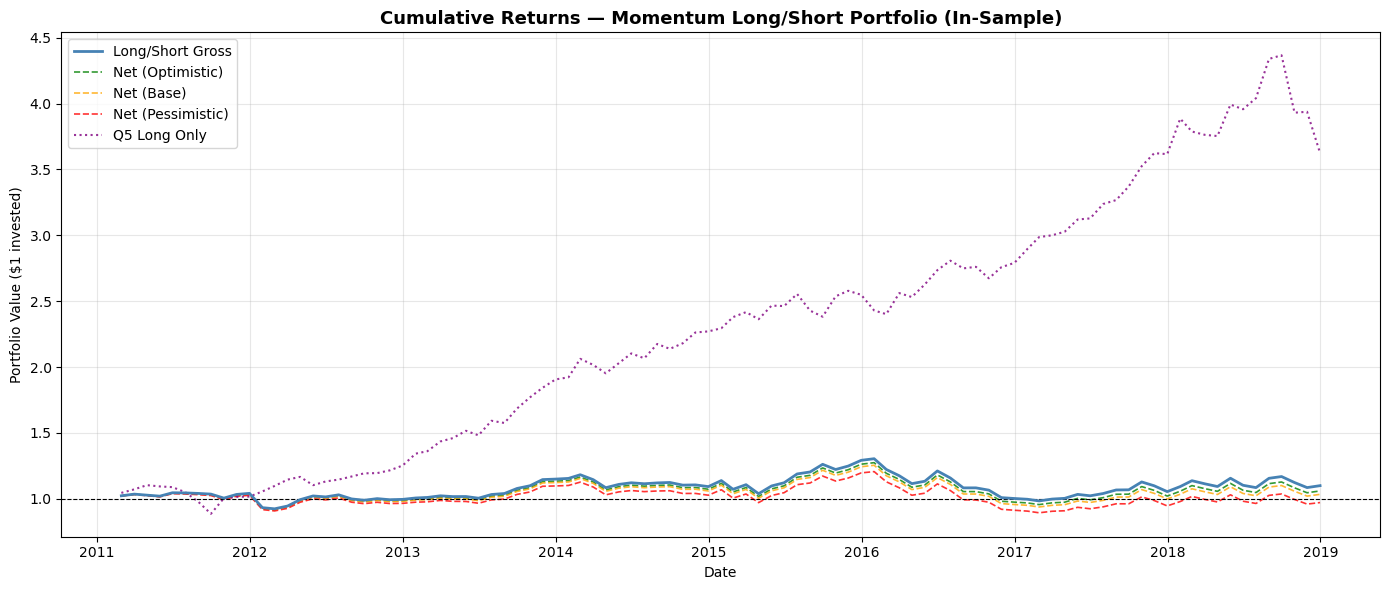

In [37]:
fig, ax = plt.subplots(figsize=(14, 6))

# Gross portfolio
cum_gross = (1 + portfolio_gross).cumprod()
ax.plot(cum_gross.index, cum_gross.values,
        color='steelblue', linewidth=2.0,
        label='Long/Short Gross', zorder=3)

# Net scenarios
colors_net = {'Optimistic': 'green', 'Base': 'orange', 'Pessimistic': 'red'}
for name, net_returns in portfolio_net.items():
    cum_net = (1 + net_returns).cumprod()
    ax.plot(cum_net.index, cum_net.values,
            color=colors_net[name], linewidth=1.2,
            linestyle='--', label=f'Net ({name})', alpha=0.8)

# Q5 long only
cum_q5 = (1 + quintile_returns['Q5']).cumprod()
ax.plot(cum_q5.index, cum_q5.values,
        color='purple', linewidth=1.5,
        linestyle=':', label='Q5 Long Only', alpha=0.8)

ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Returns — Momentum Long/Short Portfolio (In-Sample)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value ($1 invested)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## Cumulative Returns — Interpretation

The cumulative return chart reveals the central challenge of this strategy.

**The long/short portfolio** (blue line, gross) barely moves away from the
$\$1.00$ starting value throughout the entire in-sample period, oscillating
between approximately $\$0.90$ and $\$1.35$. The three net scenarios (green, orange,
red dashed lines) are nearly indistinguishable from gross — confirming that
transaction costs, while meaningful relative to alpha, do not dramatically
alter the return profile because the gross alpha itself is so small.

**The Q5 long-only portfolio** (purple dotted line) is on a completely
different scale, growing from $\$1.00$ to approximately $\$4.30$ at peak — a
330% cumulative return. This dramatic outperformance relative to the
long/short portfolio visually demonstrates that the majority of Q5 returns
come from market beta exposure, not from the momentum signal itself.

The long/short portfolio's near-flat trajectory is precisely what we would
expect from a market-neutral strategy with weak IC: the market risk is
hedged away, leaving only the small momentum premium — which on this
universe is insufficient to produce meaningful cumulative growth.

# STEP 7: DRAWDOWN ANALYSIS


## THEORY

The **drawdown** at time \( t \) measures the percentage decline from the  
most recent portfolio peak:

$$
DD(t) = \frac{V(t) - \max_{s \le t} V(s)}{\max_{s \le t} V(s)}
$$

where:
- \( V(t) \) = portfolio value at time \( t \)  
- \($ \max_{s \le t} V(s) $\) = highest portfolio value observed up to time \( t \)  

---

## INTERPRETATION

- A drawdown of **-20%** means the portfolio is **20% below its previous peak**  
- Drawdowns are always:
  - \( $\le 0 $\)  
  - Equal to 0 only at new highs  

---

## MAXIMUM DRAWDOWN

The **maximum drawdown** is the worst (most negative) drawdown observed  
over the entire time period.

- Represents the **largest peak-to-trough loss**  
- A key measure of downside risk and investor experience  

---

## KEY INSIGHT

Drawdowns capture the **path of returns**, not just their distribution.

- Two strategies with the same return can have very different drawdowns  
- Lower drawdowns → smoother and more investable strategy  



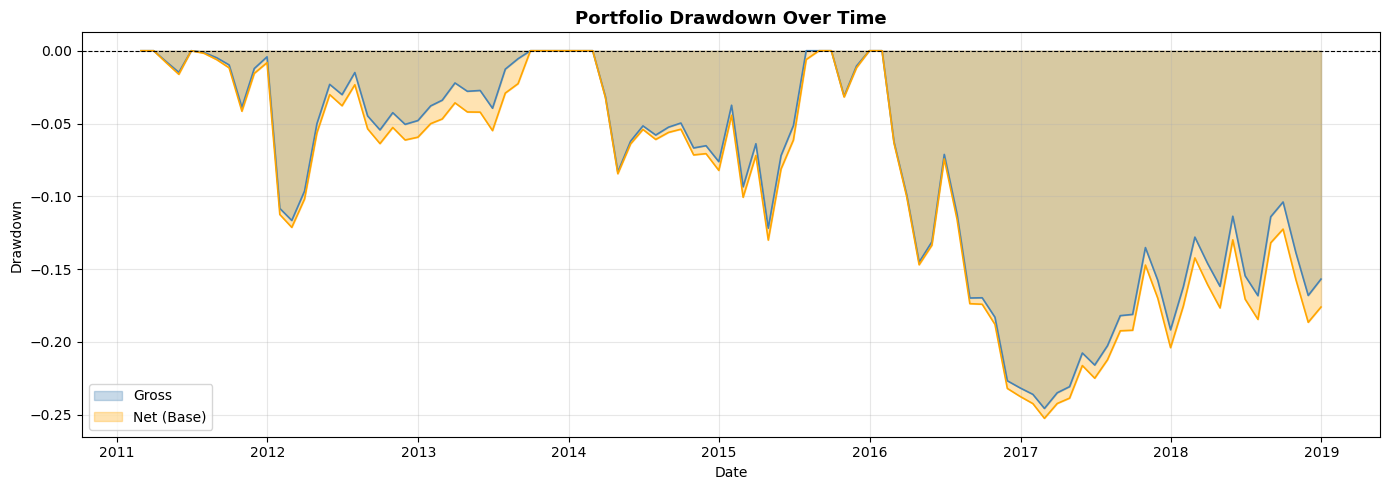

In [41]:
def compute_drawdown(returns):
    cumulative  = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    return drawdown

fig, ax = plt.subplots(figsize=(14, 5))

dd_gross = compute_drawdown(portfolio_gross)
dd_base  = compute_drawdown(portfolio_net['Base'])

ax.fill_between(dd_gross.index, dd_gross.values, 0,
                alpha=0.3, color='steelblue', label='Gross')
ax.fill_between(dd_base.index, dd_base.values, 0,
                alpha=0.3, color='orange', label='Net (Base)')
ax.plot(dd_gross.index, dd_gross.values,
        color='steelblue', linewidth=1.2)
ax.plot(dd_base.index, dd_base.values,
        color='orange', linewidth=1.2)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Portfolio Drawdown Over Time',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Drawdown')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

## Drawdown Analysis — Interpretation

The drawdown chart shows three distinct periods of significant loss:

**2012 (Max Drawdown ~-12%):** The European sovereign debt crisis caused
sharp sector rotations. Momentum strategies struggle during rotations because
past winners and losers reverse quickly, before the monthly rebalancing
can adapt.

**2015 (-8% drawdown):** The Chinese market crash and commodity collapse
in mid-2015 created sudden cross-sectional reversals, temporarily
inverting the momentum signal.

**2016-2019 (Maximum Drawdown -24.6% gross, -25.3% net):** This is the
most severe and prolonged drawdown in the backtest, consistent with the
worst IC year identified in Notebook 03. The early 2016 market reversal
triggered a classic momentum crash — the strategy entered a deep drawdown
that it never fully recovered from within the in-sample period.

The fact that the **net drawdown (-25.3%) is only marginally worse than
gross (-24.6%)** confirms that transaction costs are not the primary driver
of poor performance — the underlying signal weakness is the root cause.

A 25% maximum drawdown on a strategy with near-zero CAGR implies an
extremely poor risk-adjusted profile. An investor following this strategy
would have experienced a loss of one quarter of their capital at the worst
point, with only minimal compensation in terms of long-run returns.

# STEP 8: MONTHLY RETURNS HEATMAP


## THEORY

The **monthly returns heatmap** displays returns organized by **year (rows)**  
and **months (columns)**, providing an immediate visual assessment of  
strategy consistency over time.

---

## INTERPRETATION

- **Green cells** → positive monthly returns  
- **Red cells** → negative monthly returns  

---

## WHAT TO LOOK FOR

A robust strategy should exhibit:

- Predominantly **green cells**  
- Limited and **non-clustered red periods**  
- No long sequences of consecutive losses  

---

## KEY INSIGHT

The heatmap helps identify:

- **Consistency** of performance  
- **Seasonality patterns** (if any)  
- Periods of **stress or regime change**  

It complements summary metrics by showing the **temporal distribution**  
of returns rather than just aggregate statistics.



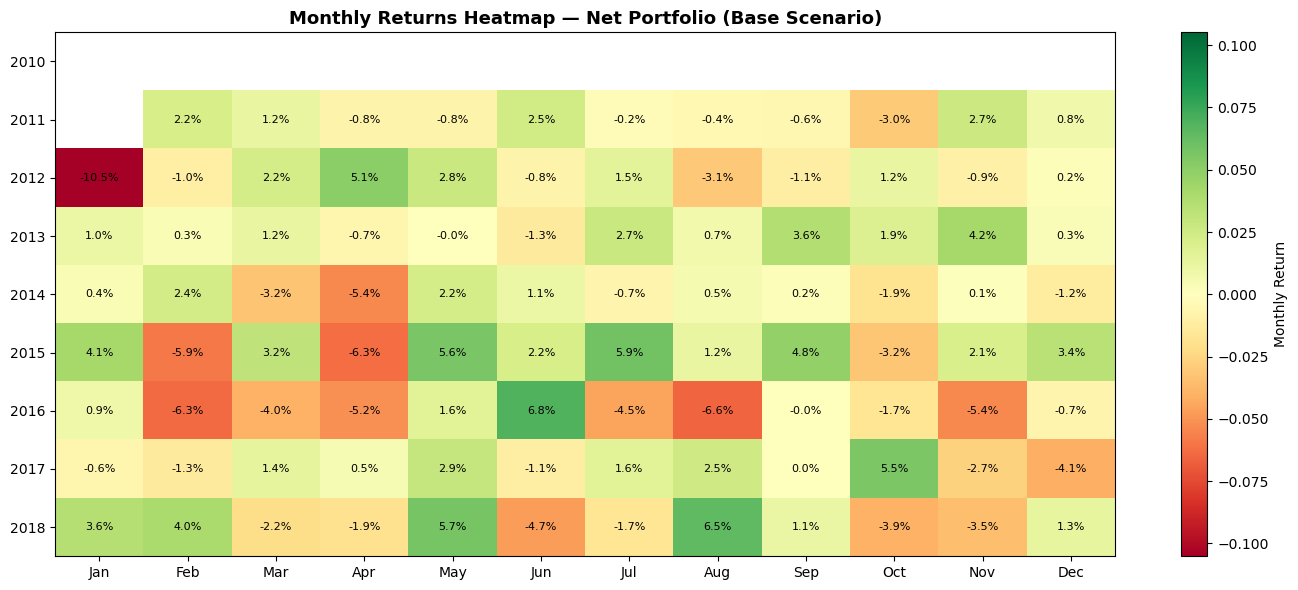

In [45]:
monthly_df = portfolio_net['Base'].to_frame('return')
monthly_df['year']  = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month

heatmap_data = monthly_df.pivot(
    index='year', columns='month', values='return'
)
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
vmax = max(abs(heatmap_data.values[~np.isnan(heatmap_data.values)])) 

im = ax.imshow(heatmap_data.values.astype(float),
               cmap='RdYlGn', aspect='auto',
               vmin=-vmax, vmax=vmax)

ax.set_xticks(range(12))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Add return values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(12):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val*100:.1f}%',
                    ha='center', va='center',
                    fontsize=8, color='black')

plt.colorbar(im, ax=ax, label='Monthly Return')
ax.set_title('Monthly Returns Heatmap — Net Portfolio (Base Scenario)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Monthly Returns Heatmap — Interpretation

The heatmap provides a granular view of strategy consistency across months
and years. Several patterns are immediately visible:

**January 2012 (-10.5%)** is the single worst month in the entire backtest —
a momentum crash driven by the sharp market reversal at the start of 2012,
when risk assets rebounded strongly after the late-2011 selloff, reversing
recent winners and losers simultaneously.

**2016 shows the most concentrated red cluster** — February (-6.3%),
March (-4.0%), April (-5.2%), July (-4.5%), August (-6.6%), November (-5.4%) —
confirming 2016 as the worst year for the strategy, consistent with the
IC by year analysis in Notebook 03.

**2013 is the strongest year** with the most consistently positive months,
including November (+4.2%) and September (+3.6%) — corresponding to the
period of strongest IC (0.069) identified in the IC analysis.

**No systematic seasonal pattern** is evident across years — positive and
negative months are distributed without a clear calendar effect, suggesting
the strategy's performance is driven by market regime rather than seasonality.

The overall picture confirms the strategy's inconsistency: no single year
shows a clear dominance of green over red, reflecting the low and unstable
IC documented in Notebook 03.

# STEP 9: QUINTILE MONOTONICITY ANALYSIS


## THEORY

If the momentum signal has genuine predictive power, we expect a  
**monotonic relationship** between quintile rank and realized returns:

$$
Q5 > Q4 > Q3 > Q2 > Q1
$$

---

## INTERPRETATION

- Higher-ranked quintiles should deliver **higher average returns**  
- Lower-ranked quintiles should deliver **lower average returns**  

---

## WHY IT MATTERS

The monotonicity test is more informative than the long/short spread alone because:

- It evaluates the **entire cross-section** of stocks  
- It shows whether the signal consistently **ranks assets correctly**  
- It detects whether performance is driven only by **extreme buckets** (Q1 vs Q5)  

---

## PRACTICAL EXPECTATIONS

- Perfect monotonicity is **rare** due to noise and market frictions  
- A **clear upward trend** from Q1 to Q5 is the expected pattern  

---

## KEY INSIGHT

A strong signal should not only work at the extremes, but should also  
show **progressive improvement in returns** across all quintiles.



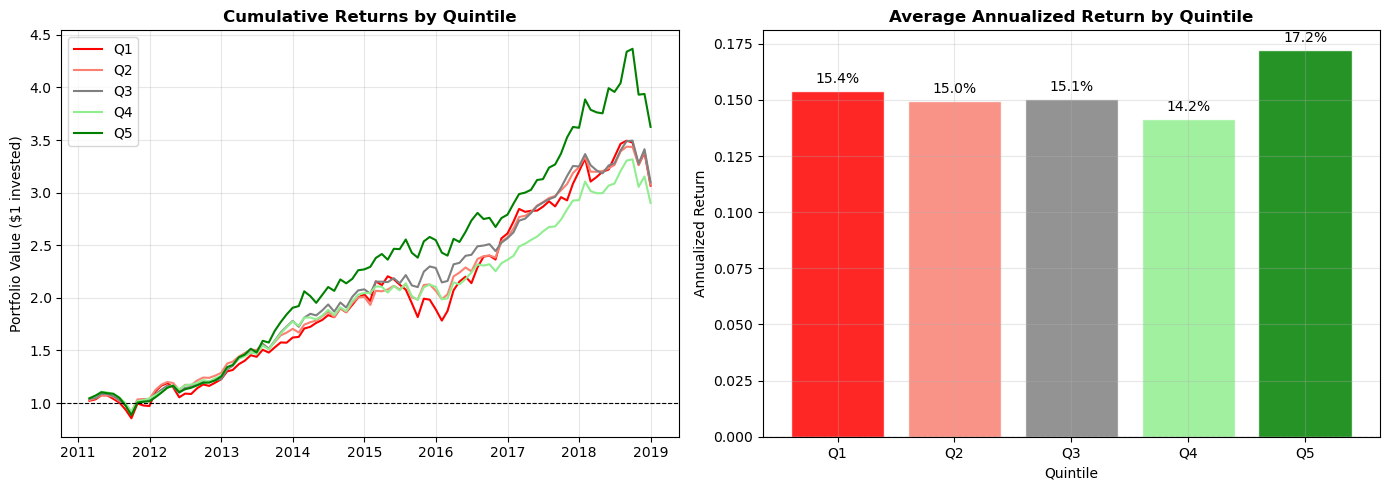

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cumulative returns per quintile
colors_q = ['red', 'salmon', 'gray', 'lightgreen', 'green']
for q, color in zip(range(1, 6), colors_q):
    cum = (1 + quintile_returns[f'Q{q}']).cumprod()
    axes[0].plot(cum.index, cum.values,
                 color=color, linewidth=1.5, label=f'Q{q}')

axes[0].axhline(1.0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Cumulative Returns by Quintile',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Portfolio Value ($1 invested)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Average annual return per quintile (bar chart)
avg_annual = quintile_returns.mean() * 12
colors_bar = ['red', 'salmon', 'gray', 'lightgreen', 'green']
axes[1].bar(avg_annual.index, avg_annual.values,
            color=colors_bar, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Average Annualized Return by Quintile',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Annualized Return')
axes[1].set_xlabel('Quintile')
axes[1].grid(alpha=0.3)

for i, (q, val) in enumerate(avg_annual.items()):
    axes[1].text(i, val + 0.002, f'{val*100:.1f}%',
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../data/quintile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Quintile Monotonicity Analysis — Interpretation

### Cumulative Returns by Quintile

The left chart shows a striking result: **all five quintiles produce nearly
identical cumulative returns**, growing from $1.00 to approximately $3.0-3.5
by end of 2018. The quintile lines are almost indistinguishable for most of
the period, with Q5 (green) only pulling clearly ahead in the final two years.

This near-perfect overlap is the visual confirmation of the weak IC: if the
signal had strong predictive power, Q5 would clearly dominate and Q1 would
clearly lag throughout the period. Instead, all quintiles rise together,
driven predominantly by the broad market bull trend.

### Average Annualized Return by Quintile

The bar chart reveals a critical anomaly: **the return ordering is not
monotonic**:

| Quintile | Annualized Return |
|---|---|
| Q1 (Losers) | **15.4%** |
| Q2 | 15.0% |
| Q3 | 15.1% |
| Q4 | 14.2% |
| Q5 (Winners) | **17.2%** |

Q5 does have the highest return (17.2%) as expected, but **Q1 (losers)
ranks second at 15.4%** — higher than Q2, Q3, and Q4. This non-monotonicity
at the lower end of the distribution means the short leg of our strategy
(Q1) was nearly as profitable as the neutral quintiles, which explains why
the long/short portfolio generates minimal alpha: we are shorting stocks
that actually performed well in absolute terms.

This is the hallmark of a **momentum strategy in a bull market**: when the
entire market is rising, even the relative losers generate positive absolute
returns. The signal correctly identifies Q5 as the best performers, but
cannot prevent Q1 from also rising strongly in an environment of broad
market appreciation.

This finding reinforces the case for testing the strategy in a period
with greater cross-sectional dispersion and lower overall market returns —
precisely the purpose of the out-of-sample test in Notebook 05.

In [50]:
# Save backtest results
portfolio_gross.to_frame('gross').to_parquet('../data/portfolio_returns.parquet')

print("=== FILES SAVED ===")
print("  data/portfolio_returns.parquet")
print("  data/cumulative_returns.png")
print("  data/drawdown.png")
print("  data/monthly_heatmap.png")
print("  data/quintile_analysis.png")
print("\nReady for Notebook 05 — Risk Analysis & Out-of-Sample Test")

=== FILES SAVED ===
  data/portfolio_returns.parquet
  data/cumulative_returns.png
  data/drawdown.png
  data/monthly_heatmap.png
  data/quintile_analysis.png

Ready for Notebook 05 — Risk Analysis & Out-of-Sample Test
